# SetUp

In [11]:
!pip install -q langgraph langchain openai langsmith graphviz
!pip install -q langchain_community --upgrade

import os
from langchain.chat_models import ChatOpenAI
from langgraph.graph import StateGraph, END
from langsmith import traceable
from typing import Dict, Any
import graphviz

In [12]:
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "multi-agent-collab-langgraph"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = ""  # Replace this securely
os.environ["OPENAI_API_KEY"] = "sk---"

# Role 1: Researcher Agent

In [13]:
# ---
# Role 1: Researcher Agent
@traceable(name="Researcher")
def researcher(state):
    query = state["input"]
    llm = ChatOpenAI(temperature=0)
    prompt = f"You are a research assistant. Research and collect key facts about the topic: {query}"
    research_notes = llm.invoke(prompt).content
    return {"research": research_notes, "input": query}

# Role 2: Engineer Agent

In [14]:
# ---
# Role 2: Engineer Agent
@traceable(name="Engineer")
def engineer(state):
    notes = state["research"]
    llm = ChatOpenAI(temperature=0)
    prompt = f"You are an engineer. Based on the research notes below, propose a technical solution or implementation:\n{notes}"
    tech_solution = llm.invoke(prompt).content
    return {"tech_solution": tech_solution, "input": state["input"]}

# Role 3: Reviewer Agent

In [15]:
# ---
# Role 3: Reviewer Agent
@traceable(name="Reviewer")
def reviewer(state):
    solution = state["tech_solution"]
    llm = ChatOpenAI(temperature=0)
    prompt = f"You are a critical reviewer. Read the proposed solution and write a concise evaluation:\n{solution}"
    review = llm.invoke(prompt).content
    return {"final_answer": review}

# Build LangGraph

In [16]:
# ---
# Build LangGraph
workflow = StateGraph(state_schema=Dict[str, Any])
workflow.add_node("researcher", researcher)
workflow.add_node("engineer", engineer)
workflow.add_node("reviewer", reviewer)

workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "engineer")
workflow.add_edge("engineer", "reviewer")
workflow.set_finish_point("reviewer")

graph = workflow.compile()

# Visualize the Multi-Agent Graph

In [17]:
# ---
# Visualize the Multi-Agent Graph
from graphviz import Digraph
viz = Digraph()
viz.attr(rankdir="LR")
viz.node("researcher", shape="box")
viz.node("engineer", shape="box")
viz.node("reviewer", shape="box")
viz.node("END", shape="oval")

viz.edge("researcher", "engineer")
viz.edge("engineer", "reviewer")
viz.edge("reviewer", "END")

viz.render("multi_agent_collab_graph", format="png", cleanup=False, view=True)

'multi_agent_collab_graph.png'

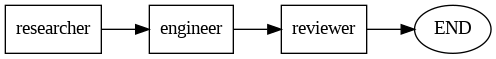

In [18]:
viz.render("react_langgraph_simple", format="png", cleanup=False, view=True)

from IPython.display import Image, display
display(Image(filename="multi_agent_collab_graph.png"))

# Run Example

In [19]:
# ---
# Run Example
inputs = {"input": "How can AI improve sustainable agriculture?"}
output = graph.invoke(inputs)
print("\nFinal Output:\n", output["final_answer"])


Final Output:
 Evaluation:

The proposed integrated AI platform for precision agriculture addresses the challenges in agriculture by leveraging data from various sources to provide real-time insights and recommendations to farmers. The key features of data integration, analysis, decision support, monitoring, and user-friendly interface are well thought out and comprehensive. 

The platform has the potential to revolutionize sustainable agriculture by enabling data-driven decision-making, optimizing resource use, improving productivity, and reducing environmental impact. However, the effectiveness of the platform would depend on the accuracy and reliability of the data collected from sensors, drones, satellite imagery, and other sources. 

Additionally, the cost of implementing and maintaining such a sophisticated AI platform may be a barrier for small-scale farmers. Overall, while the proposed solution has great potential, further research and testing are needed to evaluate its practi

In [20]:
# ---
# Run Example
inputs = {"input": "What are the risks of autonomous vehicles??"}
output = graph.invoke(inputs)
print("\nFinal Output:\n", output["final_answer"])


Final Output:
 Evaluation:

The proposed solution of implementing a secure and robust Artificial Intelligence (AI) system to address cybersecurity threats, malfunctioning technology, lack of human intervention, and data privacy concerns in autonomous vehicles is comprehensive and addresses key issues facing this technology. The AI system's ability to monitor and control various components, detect and prevent cyber attacks, switch to backup systems in case of malfunctions, and ensure data privacy is commendable.

However, the effectiveness of this solution would depend on the AI system's design, implementation, and integration with existing infrastructure systems. Additionally, the potential challenges of AI system vulnerabilities, ethical considerations, and the need for continuous updates and maintenance should be carefully considered.

Overall, the proposed solution shows promise in enhancing the safety and reliability of autonomous vehicles, but further research and testing would b

In [21]:
# ---
# More Prompts to Try
print("""
Try prompts like:
- How can drones be used for emergency response?
- What are the risks of autonomous vehicles?
- Explain how LLMs could support education in rural areas.
""")


Try prompts like:
- How can drones be used for emergency response?
- What are the risks of autonomous vehicles?
- Explain how LLMs could support education in rural areas.

